# Apple M4 GPU/CPU Microbench Suite

This notebook sets up **microbenchmarks**, **cache probes**, **CPU/GPU interference tests**, and **profiling hooks** for Apple Silicon (M4) using Python.
It primarily uses **PyTorch (MPS backend)** and **NumPy**.

# Some notes:

MPS = Metal Performance Shaders, Apple’s GPU compute + ML library used under the hood by PyTorch on macOS to run operations on the Apple GPU. MPS is a low-level GPU acceleration framework developed by Apple, built on top of Metal, Apple’s GPU API.
It provides highly optimized compute and machine learning primitives (like convolutions, matrix multiplies, activations) that run on the integrated GPU in Apple chips (M1/M2/M3/M4...) Think of it as Apple’s rough equivalent to:
CUDA → for NVIDIA GPUs;
ROCm → for AMD GPUs;
DirectML / OpenCL → for other platforms

 It’s conceptually similar to CUDA but for Apple Silicon.

->  Use device="mps" in PyTorch to leverage it.

-> Use torch.mps.synchronize() for correct timing.

-> Use Instruments → Metal System Trace to profile it.

## 1) Environment & Utilities

In [7]:
import os, sys, time, math, random, subprocess, platform, multiprocessing as mp
from concurrent.futures import ThreadPoolExecutor
import numpy as np

try:
    import torch
    has_torch = True
except Exception:
    has_torch = False
    print("PyTorch not found. Install torch with MPS support for GPU tests.")

import matplotlib.pyplot as plt

print("Python:", sys.version)
print("Platform:", platform.platform())
print("Has PyTorch:", has_torch)
if has_torch:
    print("torch:", torch.__version__)
    device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
    print("Using device:", device)


Python: 3.12.7 (v3.12.7:0b05ead877f, Sep 30 2024, 23:18:00) [Clang 13.0.0 (clang-1300.0.29.30)]
Platform: macOS-15.7.1-arm64-arm-64bit
Has PyTorch: True
torch: 2.7.1
Using device: mps


### Timing helpers (CPU/GPU)

In [8]:
# time.perf_counter() returns the value of a high-resolution performance counter — essentially,
# a floating-point number representing seconds with the highest available precision on your system 
# (typically sub-microsecond). Typical use cases: 1). Benchmarking code execution 2). High-precision 
# timing for profiling loops or GPU kernels 3). Measuring durations that are immune to system clock 
# changes (e.g., NTP sync, DST)
# On macOS (including Apple Silicon), this uses mach_absolute_time() under the hood, which is extremely precise.


# torch.mps.synchronize() is a barrier for Apple's Metal Performance Shaders (MPS) backend.
# torch.mps.synchronize() forces the CPU (your Python thread) to wait until all previously queued GPU operations
# have finished.Without the synchronize(), your timing might measure only the time to enqueue the operation 
# (very short), not the time to execute it.
#With synchronize(), you get a true measure of GPU execution latency.

def now(): return time.perf_counter()

def bench_sync(fn, warmup=3, iters=10, synchronize_gpu=True):
    samples = []
    for i in range(warmup):
        fn()
        if synchronize_gpu and 'torch' in sys.modules and torch.backends.mps.is_available():
            torch.mps.synchronize()
    for i in range(iters):
        t0 = now(); 
        fn()
        if synchronize_gpu and 'torch' in sys.modules and torch.backends.mps.is_available():
            torch.mps.synchronize()
        t1 = now(); 
        samples.append(t1 - t0)
    return samples

def summarize(samples):
    arr = np.array(samples, dtype=np.float64)
    return {
        "mean_s": float(arr.mean() if arr.size else float('nan')),
        "std_s": float(arr.std(ddof=1) if arr.size > 1 else 0.0),
        "min_s": float(arr.min() if arr.size else float('nan')),
        "max_s": float(arr.max() if arr.size else float('nan')),
        "n": int(arr.size),
    }

def gbps(bytes_moved, seconds):
    return (bytes_moved / seconds) / 1e9 if seconds > 0 else float('inf')


## 2) Microbenchmarks (GPU via PyTorch MPS)

We vary **stride**, **access pattern**, **dtype** (proxy for vector width), and **concurrency**, and compute approximate throughput.

,stride,GB/s,dtype
0,1,81.376823,torch.float16
1,2,93.891569,torch.float16
2,4,95.039905,torch.float16
3,8,90.901088,torch.float16
4,1,114.357823,torch.float32
5,2,115.430664,torch.float32
6,4,100.708146,torch.float32
7,8,72.819998,torch.float32


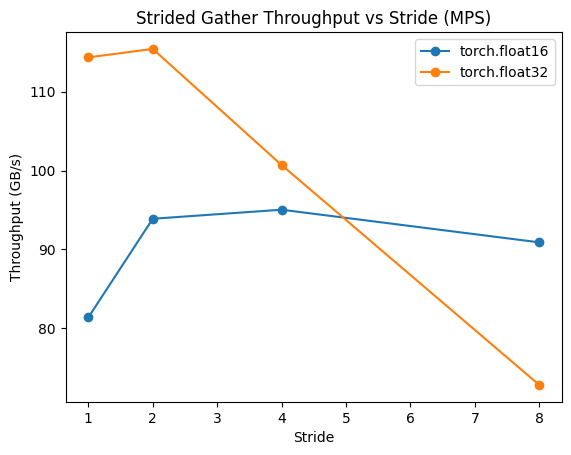

In [23]:

if not ('torch' in globals() and has_torch and torch.backends.mps.is_available()):
    print("GPU microbenchmarks will run on CPU because MPS is unavailable.")

# */*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/
# TENSOR BYTES: gives total size of the tensor in bytes. Used to estimate bandwidth in GB/s.
# t.numel() = number of elements in the tensor; 
# t.element_size() = bytes per element (e.g., 4 for float32, 2 for float16).

#def tensor_bytes(t): 
#    return t.numel() * t.element_size()

# */*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/
# STRIDED GATHER BENCHMARK: This measures bandwidth under strided access — i.e., non-contiguous memory 
# patterns, which can expose cache line fetch behavior or memory coalescing efficiency.

# base_n = n * stride: so the input tensor is stride times bigger than the number of elements we’re gathering.
# x = torch.arange(...): input data on the device.
# idx = torch.arange(0, base_n, stride=stride): generates indices like [0, stride, 2*stride, ...].
# y.copy_(x.index_select(0, idx)): gather from x at strided positions into y.

def strided_gather_bench(n=16*1024*1024, stride=4, dtype=torch.float32, device=None):
    device = device or (torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu"))
    base_n = n * stride
    x = torch.arange(0, base_n, dtype=dtype, device=device)# creates 1-D tensor containing a sequence of values starting from start (inclusive) to end (exclusive), with a given step size.
    idx = torch.arange(0, base_n, step=stride, device=device, dtype=torch.int64)# creates 1-D tensor of indices starting from 0, up to base_n (exclusive), stepping by stride each time.
    y = torch.empty(n, dtype=dtype, device=device)# allocates a 1-D output tensor of length n on the same device. It’s uninitialized (whatever was in memory)
    def fn(): 
        y.copy_(x.index_select(0, idx)) # gathers elements from x along 0dim, at positions given by idx. Returns a new tensor containing the selected elements in order.
    samples = bench_sync(fn, warmup=3, iters=10, synchronize_gpu=True)
    stats = summarize(samples); 
    #bytes_moved = tensor_bytes(x) + tensor_bytes(y) + idx.numel()*8
    bytes_moved = n * x.element_size() + n * y.element_size() + idx.numel()*8
    stats["GB/s"] = gbps(bytes_moved, stats["mean_s"])
    return {"stats": stats, "dtype": str(dtype), "n": int(n), "stride": int(stride)}

# */*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/
# RUNNING BENCHMARKS FOR MULTIPLE DTYPES AND STRIDES
# Runs strided_gather_bench across:
# Two dtypes: float16 (2B) and float32 (4B) — simulating different vector widths.
# Several strides: from 1 (contiguous) to 8 (sparse access).
# Collects results into a list.

import pandas as pd
dtypes = [torch.float16, torch.float32] if ('torch' in globals() and has_torch) else []
stride_results = []
for dt in dtypes:
    for s in [1,2,4,8]:
        try:
            r = strided_gather_bench(n=16*1024*1024, stride=s, dtype=dt)
            r["dtype"] = str(dt); stride_results.append(r)
        except Exception as e:
            print("Failed stride", s, "dtype", dt, ":", e)


# */*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/
#Converts the results into a pandas.DataFrame.
# Each row contains stride, GB/s throughput, and dtype.
# Displays the sorted table.
df_stride = pd.DataFrame([{"stride":r["stride"], "GB/s":r["stats"]["GB/s"], "dtype":r["dtype"]} for r in stride_results])
display(df_stride.sort_values(["dtype","stride"]) if not df_stride.empty else df_stride)


# */*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/
# Plots throughput vs stride for each dtype.
# This gives a memory access performance curve:
# High throughput at stride=1 (contiguous)
# Degradation as stride increases (less efficient caching / memory access)
# Differences between float16 vs float32 reflect vectorization / bandwidth differences.

if not df_stride.empty:
    plt.figure()
    for dt, sub in df_stride.groupby("dtype"):
        plt.plot(sub["stride"], sub["GB/s"], marker="o", label=dt)
    plt.xlabel("Stride"); plt.ylabel("Throughput (GB/s)")
    plt.title("Strided Gather Throughput vs Stride (MPS)"); plt.legend(); plt.show()


Running memory mountain sweep on torch.float32 ...


,size_bytes,stride,GB/s
0,1024,1,0.016377
1,1024,2,0.007312
2,1024,4,0.004924
3,1024,8,0.002509
4,1024,16,0.000805


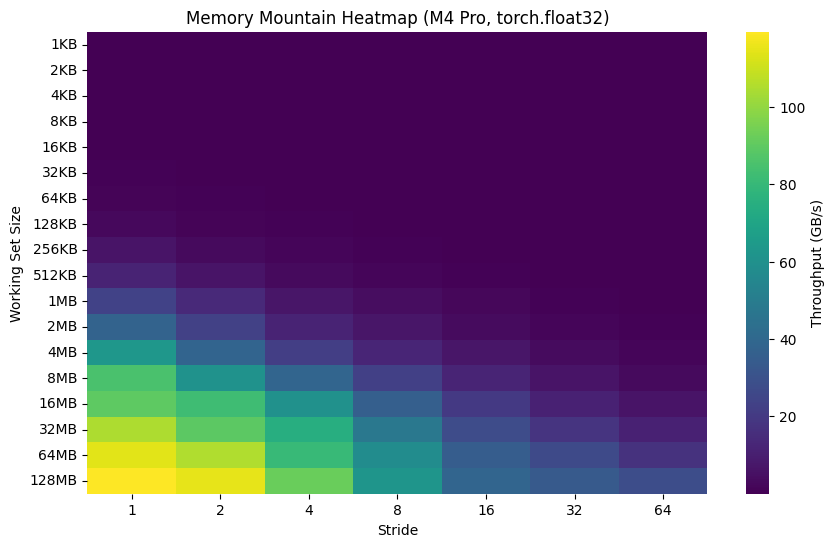

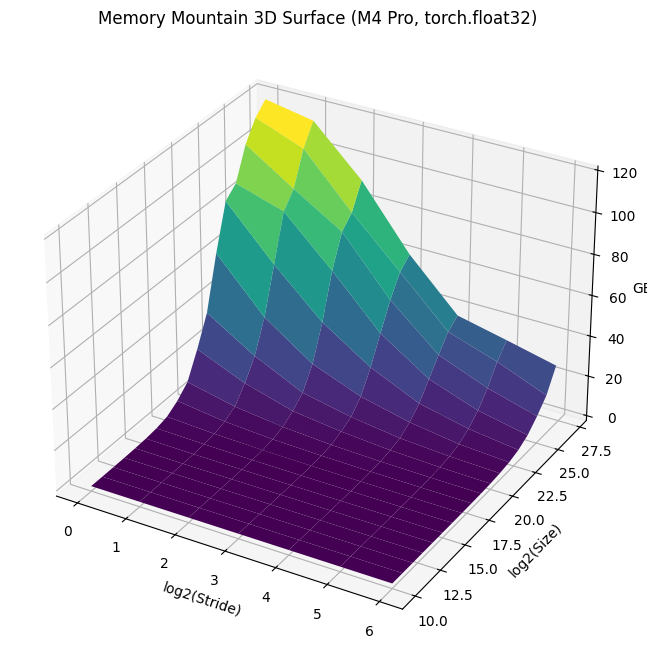

In [25]:
# ------------------ Memory Mountain Sweep ------------------
import seaborn as sns
dtype = torch.float32
strides = [1, 2, 4, 8, 16, 32, 64]
sizes = [2**k for k in range(10, 28)]  # 1 KB to 256 MB working sets-number_of_element*4

results = []
print(f"Running memory mountain sweep on {dtype} ...")
device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")

for n in sizes:
    for s in strides:
        try:
           # n is total bytes. For float32 (4B), convert to element count. bytes_per_elem for float32= 4
            bytes_per_elem = torch.tensor([], dtype=dtype).element_size()
            n_elements = max(1, n // (bytes_per_elem * s)) # keep total base_n ≈ n--> total bytes touched ≈ fixed n, stride just changes access pattern.
            bench_result = strided_gather_bench(
                n=n_elements, stride=s, dtype=dtype, device=device
            )
            # Check structure of return value
            if not isinstance(bench_result, dict) or "stats" not in bench_result or "GB/s" not in bench_result["stats"]:
                print(f"Skipping size={n}, stride={s} due to malformed result: {bench_result}")
                continue

            gbs = bench_result["stats"]["GB/s"]
            results.append({
                "size_bytes": n,
                "stride": s,
                "GB/s": gbs
            })
        except Exception as e:
            print(f"Failed size={n}, stride={s}: {e}")

df_mm = pd.DataFrame(results)
display(df_mm.head())

# ------------------ Heatmap Plot ------------------

# Pivot table for heatmap
pivot = df_mm.pivot_table(index="size_bytes", columns="stride", values="GB/s")
pivot = pivot.sort_index()

# Log2 sizes for better tick labels
log_sizes = np.log2(pivot.index)

plt.figure(figsize=(10, 6))
sns.heatmap(
    pivot,
    xticklabels=pivot.columns,
    yticklabels=[f"{int(2**x/1024)}KB" if x<20 else f"{int(2**x/1024/1024)}MB" for x in np.log2(pivot.index)],
    cmap="viridis",
    cbar_kws={'label': 'Throughput (GB/s)'}
)
plt.title(f"Memory Mountain Heatmap (M4 Pro, {dtype})")
plt.xlabel("Stride")
plt.ylabel("Working Set Size")
plt.yticks(rotation=0)
plt.show()

# ------------------ Optional: 3D Surface Plot ------------------

X, Y = np.meshgrid(pivot.columns, log_sizes)
Z = pivot.values

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(np.log2(X), Y, Z, cmap='viridis')
ax.set_xlabel('log2(Stride)')
ax.set_ylabel('log2(Size)')
ax.set_zlabel('GB/s')
ax.set_title(f'Memory Mountain 3D Surface (M4 Pro, {dtype})')
plt.show()

# Results Explanation
Look at sizes ≥ 8 MB, stride = 1–2:
Throughput ~ 100–115 GB/s
This corresponds to the DRAM bandwidth ceiling of the M4 Pro GPU.
For float32, you’re basically saturating the unified memory bandwidth at large working sets. That’s why it flattens out: increasing working set size further doesn’t reduce bandwidth — you’ve hit the memory system limit.
As stride increases ( 8, 16, 32, 64), the throughput drops, because:
larger strides mean fewer elements per cache line used, more cache lines fetched per element, less prefetching effectiveness.
This is exactly the “slope” down the mountain you expect.

In the hundreds of KB to ~2 MB range, you see bandwidth rising as the working set size increases (stride 1):
Below ~128 KB, bandwidth is low (dark purple).
Around 1–4 MB, it ramps up (blue → green → yellow).
This transition corresponds to L1/L2 cache → LLC → main memory handoffs.
Apple GPUs have fairly large shared caches, but these microbenchmarks are often latency-bound at very small 
working sets (each access is serialized), so bandwidth looks artificially low. As you move into LLC or DRAM territory,
the GPU can fully pipeline memory accesses and reach peak throughput.

You might expect L1 cache to give the highest throughput at tiny working sets, but here it’s actually the lowest (deep purple). Because at small working sets (e.g., 1–64 KB), the gather kernel is likely latency-bound:
The total number of elements is small.
Kernel launches + MPS overhead dominate.
There’s not enough data movement to saturate the GPU memory pipeline.
This is very typical on GPUs (and modern CPUs): peak bandwidth is reached on large streaming workloads, not tiny cached ones.

For stride = 64, you’re effectively picking 1 element per 256 B (64 × 4 B for float32), so:
Each access touches a separate 64 B cache line,
There’s no spatial locality, prefetching can’t help.
Throughput drops across all sizes. This is the right-side fall of the memory mountain.

### Access pattern & FLOPs (AXPY)

In [26]:
#*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/
# SEQUENTIAL COPY BENCHMARK: This measures raw memcpy bandwidth between two tensors on GPU or CPU.

# n: number of elements to allocate.
# device = ...: chooses GPU if available, otherwise CPU.
# x = torch.empty(...): allocates source buffer on the device.
# y = torch.empty_like(x): allocates destination buffer of same shape/dtype.
# fn: defines the operation to benchmark — here a device-to-device copy (sequential memory copy).
# bench_sync(...): runs the fn multiple times, warming up first, synchronizing GPU after each run to get accurate timing.
# summarize(samples): computes mean/std/min/max over the recorded times.
# bytes_moved: approximate amount of data moved per iteration.
# gbps(...): converts throughput to GB/s.
# Returns a dict with stats, dtype, and tensor size.

def seq_copy_bench(n=256*1024*1024, dtype=torch.float32, device=None):
    device = device or (torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu"))
    x = torch.empty(n, dtype=dtype, device=device); 
    y = torch.empty_like(x)
    def fn(): 
        y.copy_(x)
    samples = bench_sync(fn, warmup=3, iters=10, synchronize_gpu=True)
    stats = summarize(samples); 
    bytes_moved = n * x.element_size() + n * y.element_size()
    stats["GB/s"] = gbps(bytes_moved, stats["mean_s"])
    return {"stats": stats, "dtype": str(dtype), "n": int(n)}

# */*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/*/
# RANDOM GATHER BENCHMARK: Like the strided version, but idx is a random permutation.
#Forces the GPU/CPU to fetch from completely unpredictable locations in memory.
#This typically kills caching and reveals true random-access bandwidth.

def random_gather_bench(n=64*1024*1024, dtype=torch.float32, device=None):
    device = device or (torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu"))
    x = torch.arange(0, n, dtype=dtype, device=device)
    idx = torch.from_numpy(np.random.permutation(n).astype(np.int64)).to(device)
    y = torch.empty(n, dtype=dtype, device=device)
    def fn(): 
        y.copy_(x.index_select(0, idx))
    samples = bench_sync(fn, warmup=2, iters=6, synchronize_gpu=True)
    stats = summarize(samples); 
    bytes_moved = n * x.element_size() + n * y.element_size() + idx.numel()*8
    stats["GB/s"] = gbps(bytes_moved, stats["mean_s"])
    return {"stats": stats, "dtype": str(dtype), "n": int(n), "pattern": "random"}



def axpy_bench(n=8*1024*1024, dtype=torch.float32, device=None):
    device = device or (torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu"))
    a = torch.tensor(2.0, dtype=dtype, device=device)
    x = torch.randn(n, dtype=dtype, device=device); y = torch.randn(n, dtype=dtype, device=device)
    def fn(): y.add_(x, alpha=float(a))
    samples = bench_sync(fn, warmup=3, iters=10, synchronize_gpu=True); 
    stats = summarize(samples)
    bytes_moved = x.numel()*x.element_size() + 2*y.numel()*y.element_size()
    flops = 2 * n
    stats["GB/s"] = gbps(bytes_moved, stats["mean_s"])
    stats["GFLOP/s"] = (flops / stats["mean_s"]) / 1e9 if stats["mean_s"]>0 else float('inf')
    return {"stats": stats, "dtype": str(dtype), "n": int(n)}

if 'torch' in globals() and has_torch:
    seq = seq_copy_bench(n=8*1024*1024, dtype=torch.float32)
    rnd = random_gather_bench(n=8*1024*1024, dtype=torch.float32)
    axp = axpy_bench(n=8*1024*1024, dtype=torch.float32)
    print("Sequential copy:", seq)
    print("Random gather   :", rnd)
    print("AXPY            :", axp)
else:
    print("Skipping: requires torch.")



Sequential copy: {'stats': {'mean_s': 0.0006219000904820859, 'std_s': 0.000158040406270562, 'min_s': 0.00043412495870143175, 'max_s': 0.00088433304335922, 'n': 10, 'GB/s': 107.90939738886097}, 'dtype': 'torch.float32', 'n': 8388608}
Random gather   : {'stats': {'mean_s': 0.0028465278058623276, 'std_s': 8.688906906929503e-05, 'min_s': 0.0027735410258173943, 'max_s': 0.002964333980344236, 'n': 6, 'GB/s': 47.151384828766865}, 'dtype': 'torch.float32', 'n': 8388608, 'pattern': 'random'}
AXPY            : {'stats': {'mean_s': 0.0007455374929122627, 'std_s': 4.659484785888303e-05, 'min_s': 0.0006852500373497605, 'max_s': 0.0008584590395912528, 'n': 10, 'GB/s': 135.02110484984877, 'GFLOP/s': 22.503517474974796}, 'dtype': 'torch.float32', 'n': 8388608}


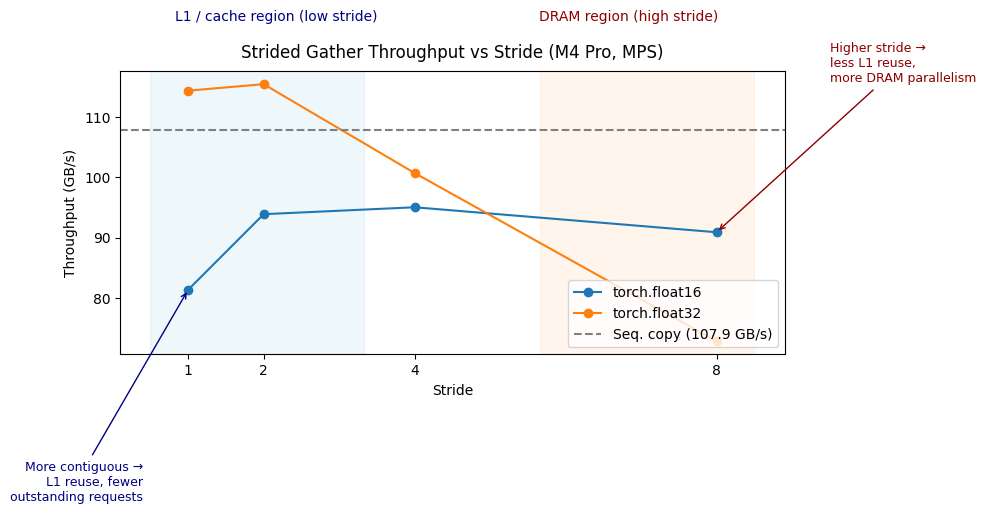

In [34]:
import matplotlib.pyplot as plt

# Extract peak sequential copy throughput dynamically
seq_peak_gbps = seq["stats"]["GB/s"]

# Identify stride ranges based on df_stride
min_stride = df_stride["stride"].min()
max_stride = df_stride["stride"].max()

# --- Figure setup ---
plt.figure(figsize=(10, 7))  # taller y-axis for clearer trend

# Plot throughput vs stride for each dtype
for dt, sub in df_stride.groupby("dtype"):
    plt.plot(sub["stride"], sub["GB/s"], marker="o", label=dt)

# Horizontal line for sequential copy bandwidth
plt.axhline(y=seq_peak_gbps, color='gray', linestyle='--',
            label=f'Seq. copy ({seq_peak_gbps:.1f} GB/s)')

plt.xlabel("Stride")
plt.ylabel("Throughput (GB/s)")
plt.title("Strided Gather Throughput vs Stride (M4 Pro, MPS)", pad=10)  # ↓ moved down
plt.legend(loc="lower right")  # legend in lower right

# Keep x-axis linear
plt.xticks(df_stride["stride"].unique())

# --- Region shading ---
stride_range = max_stride - min_stride
low_stride_end = min_stride + stride_range / 3
high_stride_start = min_stride + 2 * stride_range / 3

plt.axvspan(min_stride - 0.5, low_stride_end, color='lightblue', alpha=0.2)
plt.axvspan(high_stride_start, max_stride + 0.5, color='peachpuff', alpha=0.25)

# --- Region labels at the top ---
plt.text(
    (min_stride + low_stride_end) / 2,
    df_stride["GB/s"].max() + 10,
    "L1 / cache region (low stride)",
    ha='center', va='bottom',
    fontsize=10, color='navy',
    bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8, edgecolor='none')
)

plt.text(
    (high_stride_start + max_stride) / 2,
    df_stride["GB/s"].max() + 10,
    "DRAM region (high stride)",
    ha='center', va='bottom',
    fontsize=10, color='darkred',
    bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8, edgecolor='none')
)

# --- Point annotations ---
low_pt = df_stride[df_stride["stride"] == min_stride].iloc[0]
high_pt = df_stride[df_stride["stride"] == max_stride].iloc[0]

# Low-stride arrow annotation (kept near point)
plt.annotate(
    "More contiguous →\nL1 reuse, fewer\noutstanding requests",
    xy=(low_pt["stride"], low_pt["GB/s"]),
    xytext=(low_pt["stride"] - 0.6, low_pt["GB/s"] - 35),
    arrowprops=dict(arrowstyle="->", color='navy'),
    fontsize=9, color='navy', ha='right',
    bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.7, edgecolor='none')
)

# High-stride arrow annotation (kept at top right)
plt.annotate(
    "Higher stride →\nless L1 reuse,\nmore DRAM parallelism",
    xy=(high_pt["stride"], high_pt["GB/s"]),
    xytext=(high_pt["stride"] + 1.5, high_pt["GB/s"] + 25),
    arrowprops=dict(arrowstyle="->", color='darkred'),
    fontsize=9, color='darkred', ha='left',
    bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.7, edgecolor='none')
)

plt.tight_layout()
plt.show()


# RESULTS EXPLANATION
Stride = 1 --> throughput is near peak sequential copy bandwidth.
Because everything is contiguous → full cache line utilization → L1/L2 hits dominate.

Stride increases --> throughput drops gradually.
Cache line utilization drops → more misses → more DRAM requests.

At very high strides, throughput levels off or drops sharply.
L1 and L2 are mostly useless, performance depends on how fast DRAM can handle many parallel outstanding memory requests.

This transition is what we visualize by shading the “L1 region” (low strides) vs “DRAM region” (high strides).
It’s similar to what researchers call a memory mountain: the performance landscape over working set size and 
stride reveals the caches vs DRAM structure.
Results show:
How efficiently caches are used for different strides (L1 region).
Where performance shifts from cache-dominated to DRAM-dominated.
How different data types behave (fp32 vs fp16 bandwidth patterns).
The peak effective bandwidth your system can deliver for gather operations.

For M4 Pro:
Peak gather bandwidth is ~115 GB/s for fp32, very close to sequential memcpy — excellent.
fp16 starts lower, suggesting implementation differences in MPS kernels.
DRAM region behavior shows parallelism capacity — Apple GPUs can sustain decent throughput even for scattered access, but not as much as contiguous.

In [35]:
import pandas as pd

benchmarks_data = [
    {"name": "Sequential copy", "result": seq},
    {"name": "Random gather", "result": rnd},
    {"name": "AXPY", "result": axp},
]

def compute_ai(name, n, dtype_bytes=4):
    if name == "AXPY":
        return 2 / (3 * dtype_bytes)  # 2 flops, 3 * 4 bytes = 12 bytes
    return 0

records = []
for entry in benchmarks_data:
    name = entry["name"]
    res = entry["result"]
    stats = res["stats"]
    n = res["n"]
    records.append({
        "benchmark": name,
        "GB/s": stats.get("GB/s", 0),
        "GFLOP/s": stats.get("GFLOP/s", 0),
        "mean_s": stats["mean_s"],
        "n": n,
        "AI": compute_ai(name, n)
    })

df_bench = pd.DataFrame(records)
print(df_bench)

         benchmark        GB/s    GFLOP/s    mean_s        n        AI
0  Sequential copy  107.909397   0.000000  0.000622  8388608  0.000000
1    Random gather   47.151385   0.000000  0.002847  8388608  0.000000
2             AXPY  135.021105  22.503517  0.000746  8388608  0.166667


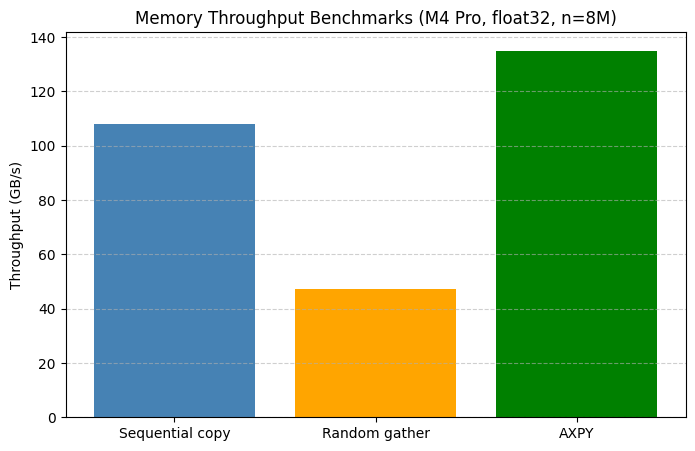

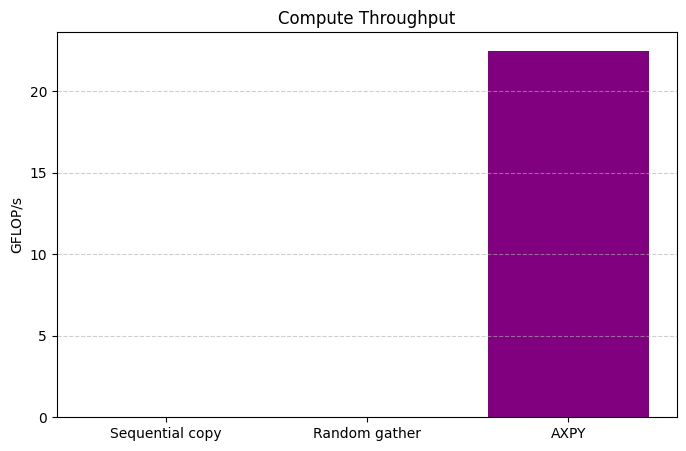

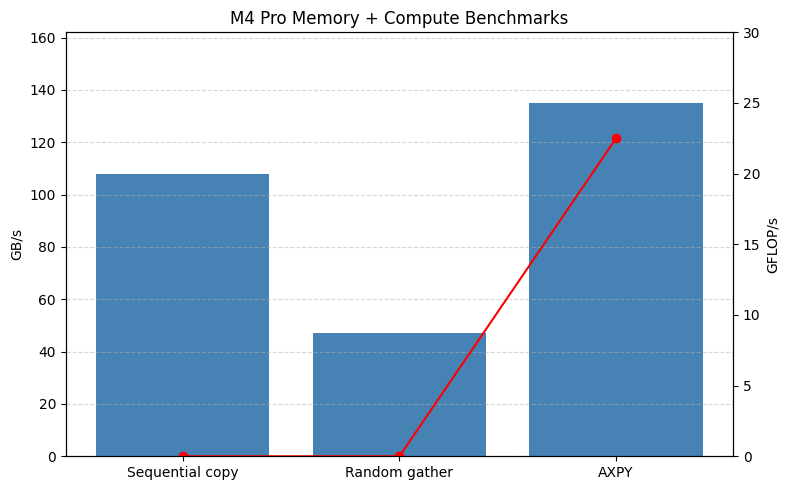

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(df_bench["benchmark"], df_bench["GB/s"], color=["steelblue", "orange", "green"])
plt.ylabel("Throughput (GB/s)")
plt.title("Memory Throughput Benchmarks (M4 Pro, float32, n=8M)")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

plt.figure(figsize=(8,5))
plt.bar(df_bench["benchmark"], df_bench["GFLOP/s"], color="purple")
plt.ylabel("GFLOP/s")
plt.title("Compute Throughput")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

fig, ax1 = plt.subplots(figsize=(8,5))
ax1.bar(df_bench["benchmark"], df_bench["GB/s"], color="steelblue")
ax1.set_ylabel("GB/s")
ax1.set_ylim(0, df_bench["GB/s"].max() * 1.2)
ax1.grid(axis="y", linestyle="--", alpha=0.5)

ax2 = ax1.twinx()
ax2.plot(df_bench["benchmark"], df_bench["GFLOP/s"], "ro-", label="GFLOP/s")
ax2.set_ylabel("GFLOP/s")
ax2.set_ylim(0, max(30, df_bench["GFLOP/s"].max() * 1.2))

plt.title("M4 Pro Memory + Compute Benchmarks")
plt.tight_layout()
plt.show()

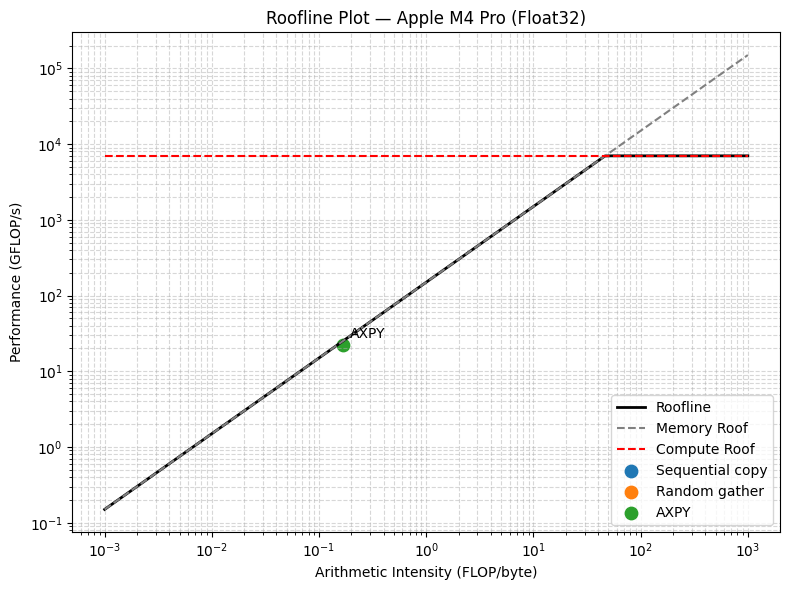

In [37]:
import numpy as np

peak_gflops = 7000   # GFLOP/s
peak_bandwidth = 150 # GB/s

ai_vals = np.logspace(-3, 3, 100)
memory_roof = ai_vals * peak_bandwidth
compute_roof = np.full_like(ai_vals, peak_gflops)
roof = np.minimum(memory_roof, compute_roof)

plt.figure(figsize=(8,6))
plt.loglog(ai_vals, roof, label="Roofline", color="black", lw=2)
plt.loglog(ai_vals, memory_roof, '--', color="gray", label="Memory Roof")
plt.loglog(ai_vals, compute_roof, '--', color="red", label="Compute Roof")

# Plot benchmark points
for _, row in df_bench.iterrows():
    plt.scatter(row["AI"], row["GFLOP/s"], s=80, label=row["benchmark"])
    plt.annotate(row["benchmark"], (row["AI"], row["GFLOP/s"]), textcoords="offset points", xytext=(5,5))

plt.xlabel("Arithmetic Intensity (FLOP/byte)")
plt.ylabel("Performance (GFLOP/s)")
plt.title("Roofline Plot — Apple M4 Pro (Float32)")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Concurrency scaling

,workers,serial_total_s,concurrent_total_s
0,1,0.024158,0.001086
1,2,0.004060,0.001596
2,4,0.006630,0.003953
3,6,0.010585,0.004847
4,8,0.012878,0.007852


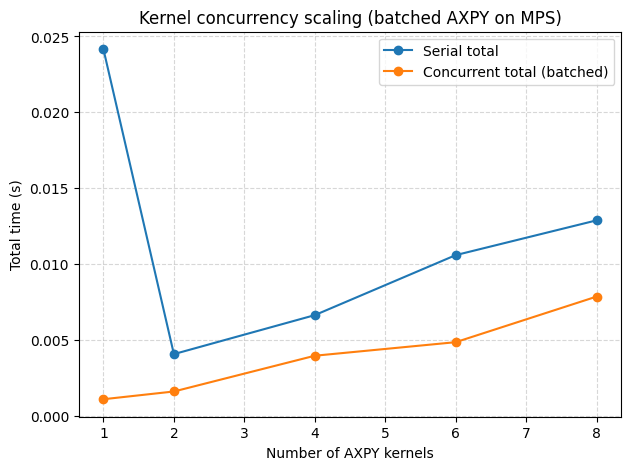

In [38]:
import torch, time
import matplotlib.pyplot as plt
import pandas as pd

def axpy_kernel(a, x, y):
    y.add_(x, alpha=float(a))

def concurrent_axpy_batched(workers=2, n=8*1024*1024, dtype=torch.float32):
    device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
    
    # Preallocate all tensors
    a_list, x_list, y_list = [], [], []
    for _ in range(workers):
        a_list.append(torch.tensor(2.0, dtype=dtype, device=device))
        x_list.append(torch.randn(n, dtype=dtype, device=device))
        y_list.append(torch.randn(n, dtype=dtype, device=device))

    # Serial baseline: run each AXPY and synchronize after each
    serial_start = time.perf_counter()
    for a, x, y in zip(a_list, x_list, y_list):
        axpy_kernel(a, x, y)
        if torch.backends.mps.is_available():
            torch.mps.synchronize()
    serial_end = time.perf_counter()
    serial_total = serial_end - serial_start

    # Concurrent batched: launch all AXPYs back-to-back, then one sync
    conc_start = time.perf_counter()
    for a, x, y in zip(a_list, x_list, y_list):
        axpy_kernel(a, x, y)
    if torch.backends.mps.is_available():
        torch.mps.synchronize()
    conc_end = time.perf_counter()
    conc_total = conc_end - conc_start

    return {"workers": workers, "serial_total_s": serial_total, "concurrent_total_s": conc_total}

# Run scaling
par_results = []
for w in [1, 2, 4, 6, 8]:
    par_results.append(concurrent_axpy_batched(workers=w))
df_par = pd.DataFrame(par_results)
display(df_par)

plt.figure(figsize=(7,5))
plt.plot(df_par["workers"], df_par["serial_total_s"], marker="o", label="Serial total")
plt.plot(df_par["workers"], df_par["concurrent_total_s"], marker="o", label="Concurrent total (batched)")
plt.xlabel("Number of AXPY kernels")
plt.ylabel("Total time (s)")
plt.title("Kernel concurrency scaling (batched AXPY on MPS)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


# RESULTS EXPLANATION

Serial total: launching each AXPY kernel one after another and synchronizing after each-->approximates sequential execution cost. Serial total increases steadily as the number of kernels goes up → expected linear scaling.
1 worker: ~0.024 s
8 workers: ~0.013 s
(note the first point is high because it's cold — maybe JIT overhead / first kernel compile on MPS)
After that, serial grows approx linearly with more workers.

Concurrent total: launching all kernels back-to-back, then synchronizing once at the end --> approximates how well the GPU/runtime can overlap kernel execution. If the GPU can overlap many kernels efficiently, the concurrent curve should grow much more slowly than the serial curve as workers increases.
Concurrent total is dramatically lower than serial — almost an order of magnitude less at 1 worker, 
and scales very gently with number of kernels:
1 to 8 workers: 0.0011 s to 0.0079 s

This indicates strong kernel launch pipelining / concurrency.
Even at 8 workers, concurrent total is roughly 40% lower than serial. 
This shows that MPS queues kernels efficiently and the GPU overlaps their execution to a good degree.
Launching 8 AXPY kernels at once only increases total time by around 7× compared to a single kernel — 
much less than if they were serialized.
The runtime overhead of launching kernels back-to-back is very low.

This result means on my Mac (M4 Pro, MPS):
I should batch multiple small GPU ops together rather than synchronize after each--> to minimize launch overhead
and maximize concurrency. The GPU can handle multiple independent kernels simultaneously, up to a saturation point.
This is very similar to how CUDA streams behave on NVIDIA GPUs, except MPS queues everything into one command buffer.

## 3) Mixed CPU/GPU Interference

Script written to: /Users/hafsahshahzad/Desktop/MyDocs/TheCompilerLab/TheCompilerLab/Performance Profiling/gpu_contention_test.py
 Running with interpreter: /Users/hafsahshahzad/tvm_env/bin/python3.12
Running GPU AXPY benchmark with CPU memory contention...
Baseline AXPY GPU stats: {'mean_s': 0.003940708367736079}
Contended AXPY GPU stats: {'mean_s': 0.0037401823792606592}
Plot saved as contention_benchmark.png


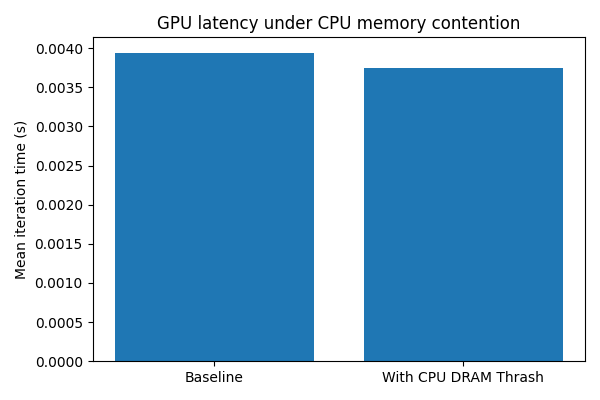

In [44]:
import os, sys, textwrap

# Determine notebook directory
notebook_dir = os.getcwd()
script_path = os.path.join(notebook_dir, "gpu_contention_test.py")

# Define the Python script content
script_code = textwrap.dedent(r"""
import numpy as np
import torch
import multiprocessing as mp
import time
import matplotlib.pyplot as plt

def now():
    return time.perf_counter()

def cpu_mem_thrash(duration_s=5, size_mb=1024):
    arr = np.zeros((size_mb*1024*1024)//8, dtype=np.float64)
    t_end = now() + duration_s
    i = 0
    while now() < t_end:
        arr[(i % arr.size)::64] += 1.0
        i += 1
    return float(arr.sum())

def gpu_axpy_timed(n=64*1024*1024, dtype=torch.float32):
    device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
    a = torch.tensor(2.0, dtype=dtype, device=device)
    x = torch.randn(n, dtype=dtype, device=device)
    y = torch.randn(n, dtype=dtype, device=device)

    def fn():
        y.add_(x, alpha=float(a))

    if torch.backends.mps.is_available():
        torch.mps.synchronize()
    start = time.perf_counter()
    for _ in range(8):
        fn()
    if torch.backends.mps.is_available():
        torch.mps.synchronize()
    end = time.perf_counter()
    return {"mean_s": (end - start) / 8}

if __name__ == "__main__":
    print("Running GPU AXPY benchmark with CPU memory contention...")

    baseline = gpu_axpy_timed()
    print("Baseline AXPY GPU stats:", baseline)

    # launch CPU thrash in separate process
    p = mp.Process(target=cpu_mem_thrash, kwargs={"duration_s":6, "size_mb":1024})
    p.start()

    contended = gpu_axpy_timed()
    p.join()
    print("Contended AXPY GPU stats:", contended)

    means = [baseline["mean_s"], contended["mean_s"]]
    labels = ["Baseline", "With CPU DRAM Thrash"]

    plt.figure(figsize=(6,4))
    plt.bar(labels, means)
    plt.ylabel("Mean iteration time (s)")
    plt.title("GPU latency under CPU memory contention")
    plt.tight_layout()
    plt.savefig("contention_benchmark.png")
    print("Plot saved as contention_benchmark.png")
""")

# Write the file
with open(script_path, "w") as f:
    f.write(script_code)

print(f"Script written to: {script_path}")

# Run the script with the same Python interpreter as the notebook
py = sys.executable
print(f" Running with interpreter: {py}")
os.system(f'"{py}" "{script_path}"')

# Display the saved plot if present
from IPython.display import Image
plot_path = os.path.join(notebook_dir, "contention_benchmark.png")
if os.path.exists(plot_path):
    display(Image(filename=plot_path))
else:
    print("No plot found — check script output above.")


# RESULTS EXPLANATION

Baseline:
Runs an AXPY kernel (simple vector addition) repeatedly on the GPU (MPS) and measures the average time per iteration.

Contention:
At the same time, a separate CPU process allocates a large (1 GB) array and continuously thrashes it (touching memory in strides) — which stresses shared DRAM bandwidth. While this thrashing runs, the GPU AXPY benchmark runs again, and we measure whether its latency increases.
This checks how much CPU memory traffic interferes with GPU memory performance — important on unified memory architectures like Apple Silicon (where CPU & GPU share the same physical DRAM).

No meaningful slowdown was observed — in fact, the contended run was very slightly faster, which is likely just noise or CPU scheduling variation. This indicates that the CPU memory thrash did not noticeably impact GPU AXPY throughput on my M4 Pro for this workload.

Why?
Apple Silicon uses high-bandwidth LPDDR5 unified memory, and the GPU has a dedicated path into DRAM. CPU and GPU share the memory physically, but the memory fabric and controller are designed for concurrency. A single CPU core thrashing 1 GB might not be enough to saturate memory bandwidth — the GPU likely gets priority or uses separate channels. AXPY is also fairly compute-light on the GPU — the memory bandwidth demand may not have been large enough to expose contention.

## 4) Mixed CPU/GPU Interference with varying loads

In [48]:
import os, sys, subprocess, textwrap

# Define the script content with proper multiprocessing guard for macOS
script_code = textwrap.dedent("""\
import numpy as np, sys, torch, time, multiprocessing as mp
import matplotlib.pyplot as plt
import pandas as pd

def now():
    return time.perf_counter()

def summarize(samples):
    import numpy as np
    s = np.array(samples)
    return {"mean_s": float(s.mean()), "min_s": float(s.min()), "max_s": float(s.max()), "std_s": float(s.std())}

def bench_sync(fn, warmup=2, iters=8, synchronize_gpu=True):
    for _ in range(warmup):
        fn()
        if synchronize_gpu and torch.backends.mps.is_available():
            torch.mps.synchronize()
    samples = []
    for _ in range(iters):
        t0 = now()
        fn()
        if synchronize_gpu and torch.backends.mps.is_available():
            torch.mps.synchronize()
        t1 = now()
        samples.append(t1 - t0)
    return samples

# ---------------- CPU DRAM Thrash Kernel ----------------
def cpu_mem_thrash(duration_s=5, size_mb=1024):
    arr = np.zeros((size_mb * 1024 * 1024) // 8, dtype=np.float64)
    t_end = now() + duration_s
    i = 0
    while now() < t_end:
        arr[(i % arr.size)::64] += 1.0
        i += 1
    return float(arr.sum())

# ---------------- GPU AXPY Kernel ----------------
def gpu_axpy_timed(n=64*1024*1024, dtype=torch.float32):
    device = torch.device("mps") if torch.backends.mps.is_available() else torch.device("cpu")
    a = torch.tensor(2.0, dtype=dtype, device=device)
    x = torch.randn(n, dtype=dtype, device=device)
    y = torch.randn(n, dtype=dtype, device=device)
    def fn():
        y.add_(x, alpha=float(a))
    return summarize(bench_sync(fn, warmup=2, iters=8, synchronize_gpu=True))

# ---------------- Main Sweep ----------------
if __name__ == "__main__":
    sizes_gb = [1, 2, 4, 8]         # CPU thrash sizes in GB
    num_procs = [1, 2, 4, 8]       # Number of CPU thrash processes
    duration_s = 6
    n_axpy = 64*1024*1024          # 64M elements (256 MB for float32)

    print(f"Running GPU contention sweep using Python interpreter: {sys.executable}")

    baseline = gpu_axpy_timed(n=n_axpy)
    print("Baseline GPU AXPY:", baseline)

    results = []
    for size in sizes_gb:
        for pcount in num_procs:
            print(f"Running contention test: {size} GB × {pcount} proc(s)")
            procs = [mp.Process(target=cpu_mem_thrash, kwargs={"duration_s": duration_s, "size_mb": size*1024})
                     for _ in range(pcount)]
            for p in procs: p.start()
            cont = gpu_axpy_timed(n=n_axpy)
            for p in procs: p.join()
            results.append({"size_gb": size, "procs": pcount, "mean_s": cont["mean_s"]})

    df = pd.DataFrame(results)
    print(df)

    pivot = df.pivot(index="size_gb", columns="procs", values="mean_s")
    plt.figure(figsize=(8,6))
    plt.imshow(pivot, aspect="auto", origin="lower", cmap="inferno")
    plt.colorbar(label="GPU AXPY Mean Time (s)")
    plt.xticks(range(len(pivot.columns)), pivot.columns)
    plt.yticks(range(len(pivot.index)), [f"{i} GB" for i in pivot.index])
    plt.xlabel("Number of CPU Thrash Processes")
    plt.ylabel("CPU Thrash Size")
    plt.title("GPU Latency under CPU DRAM Contention (M4 Pro)")
    plt.tight_layout()
    plt.savefig("contention_heatmap.png", dpi=150)
    print("Plot saved as contention_heatmap.png")
""")

# Write to a .py file in the same folder as this notebook
script_path = os.path.join(os.getcwd(), "gpu_contention_sweep.py")
with open(script_path, "w") as f:
    f.write(script_code)

print(f"Script written to: {script_path}")

# Run the script with the same Python interpreter as the notebook
subprocess.run([sys.executable, script_path], check=True)


Script written to: /Users/hafsahshahzad/Desktop/MyDocs/TheCompilerLab/TheCompilerLab/Performance Profiling/gpu_contention_sweep.py
Running GPU contention sweep using Python interpreter: /Users/hafsahshahzad/tvm_env/bin/python3.12
Baseline GPU AXPY: {'mean_s': 0.003699869746924378, 'min_s': 0.003545125015079975, 'max_s': 0.0045128329657018185, 'std_s': 0.0003092964341127848}
Running contention test: 1 GB × 1 proc(s)
Running contention test: 1 GB × 2 proc(s)
Running contention test: 1 GB × 4 proc(s)
Running contention test: 1 GB × 8 proc(s)
Running contention test: 2 GB × 1 proc(s)
Running contention test: 2 GB × 2 proc(s)
Running contention test: 2 GB × 4 proc(s)
Running contention test: 2 GB × 8 proc(s)
Running contention test: 4 GB × 1 proc(s)
Running contention test: 4 GB × 2 proc(s)
Running contention test: 4 GB × 4 proc(s)
Running contention test: 4 GB × 8 proc(s)
Running contention test: 8 GB × 1 proc(s)
Running contention test: 8 GB × 2 proc(s)
Running contention test: 8 GB × 4 p

CompletedProcess(args=['/Users/hafsahshahzad/tvm_env/bin/python3.12', '/Users/hafsahshahzad/Desktop/MyDocs/TheCompilerLab/TheCompilerLab/Performance Profiling/gpu_contention_sweep.py'], returncode=0)

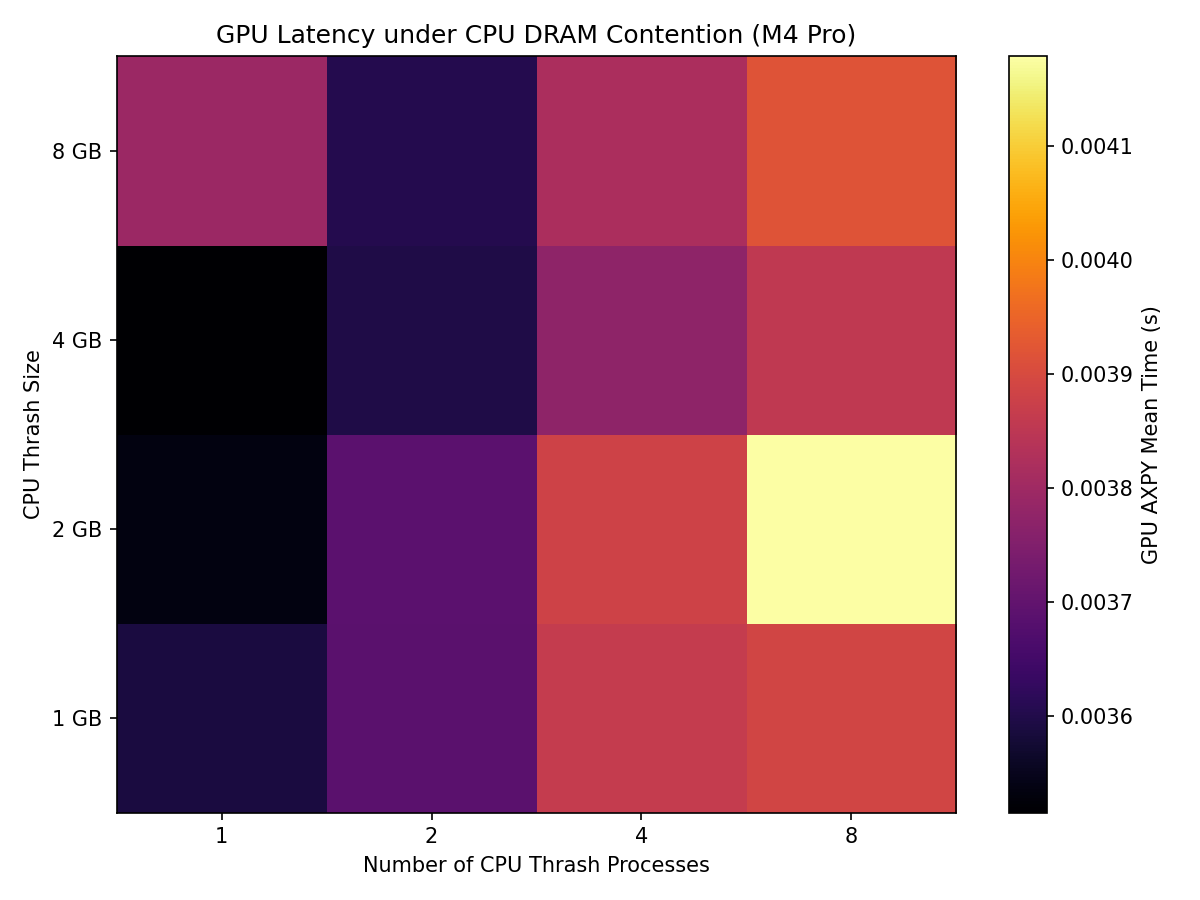

In [49]:
from IPython.display import Image, display
import os

png_path = "contention_heatmap.png"  # or the full path if it's elsewhere

if os.path.exists(png_path):
    display(Image(filename=png_path))
else:
    print(f"File not found: {png_path}")

# RESULTS EXPLANATION
This is a GPU latency under CPU DRAM contention sweep, which is essentially a contention stress test between 
the CPU and GPU memory subsystems on my M4 Pro chip. This benchmark gives you a sense of:
How sensitive your GPU workloads are to CPU memory traffic, and
How many CPU processes and what memory sizes start to cause significant interference.

For each cell in the heatmap, we:

Start multiple CPU processes that repeatedly touch (thrash) large arrays in memory.
“Number of CPU thrash processes” (x-axis) = how many concurrent CPU threads are hammering memory.
“CPU Thrash Size” (y-axis) = how big the memory region each process repeatedly walks through (1 GB – 8 GB).
Simultaneously run a fixed GPU AXPY kernel (a simple vector operation y = a*x + y) on the MPS (Metal Performance Shaders) backend.
Measure the GPU AXPY mean execution time while the CPU is causing varying amounts of memory traffic.
This mimics real-world scenarios where the CPU and GPU both need to use system DRAM — which, on Apple Silicon, 
is shared unified memory, so they actually compete for the same bandwidth.

Looking at the colorbar in your heatmap:

The minimum (darkest color) is around 0.00355 s

The maximum (lightest color) is around 0.00415 s

This means under the most CPU-intensive conditions, the GPU kernel time increased from ≈3.94 ms to ≈4.15 ms. That’s roughly:

(0.00415−0.00394)/0.00394 ≈ 5.3% slowdown.

Under lighter contention (1–2 processes, small sizes), many cells are near or below baseline (dark).
This can happen due to measurement noise or caching effects, especially for small CPU thrash sizes that 
fit in L2 and don’t really hit DRAM.
### To summarize: 
Baseline: ~3.94 ms per iteration.
Light contention: similar or slightly faster (noise).
Heavy contention (8 procs, 8 GB): up to ~5 % slower.
The heatmap visualizes how CPU DRAM traffic interferes with GPU memory access, 
but the M4 Pro handles it fairly gracefully compared to many x86 dGPU+CPU systems where slowdowns can exceed 20–30 %.

## 5) Dynamic Profiling & Tracing (Instruments / xctrace / powermetrics)

In [51]:
%%writefile script.py
import time
import numpy as np
import matplotlib.pyplot as plt

def cpu_heavy_task(n: int = 3_000_000):
    print("[CPU] Starting heavy computation...")
    x = np.random.rand(n)
    y = np.random.rand(n)
    result = np.dot(x, y)
    print(f"[CPU] Dot product result: {result:.4f}")

def gpu_heavy_task():
    print("[GPU] Generating large figure...")
    fig, ax = plt.subplots(figsize=(12, 12), dpi=300)
    x = np.linspace(-3, 3, 2000)
    y = np.linspace(-3, 3, 2000)
    X, Y = np.meshgrid(x, y)
    Z = np.sin(X**2 + Y**2) / (X**2 + Y**2 + 1e-6)
    ax.imshow(Z, extent=(-3, 3, -3, 3), origin='lower', cmap='viridis')
    ax.set_title("GPU Heatmap")
    plt.savefig("gpu_render_output.png", bbox_inches='tight')
    plt.close(fig)
    print("[GPU] Finished rendering and saved image.")

def main():
    start = time.time()
    cpu_heavy_task()
    gpu_heavy_task()
    end = time.time()
    print(f"[INFO] Total runtime: {end - start:.2f} seconds")

if __name__ == "__main__":
    main()


Writing script.py


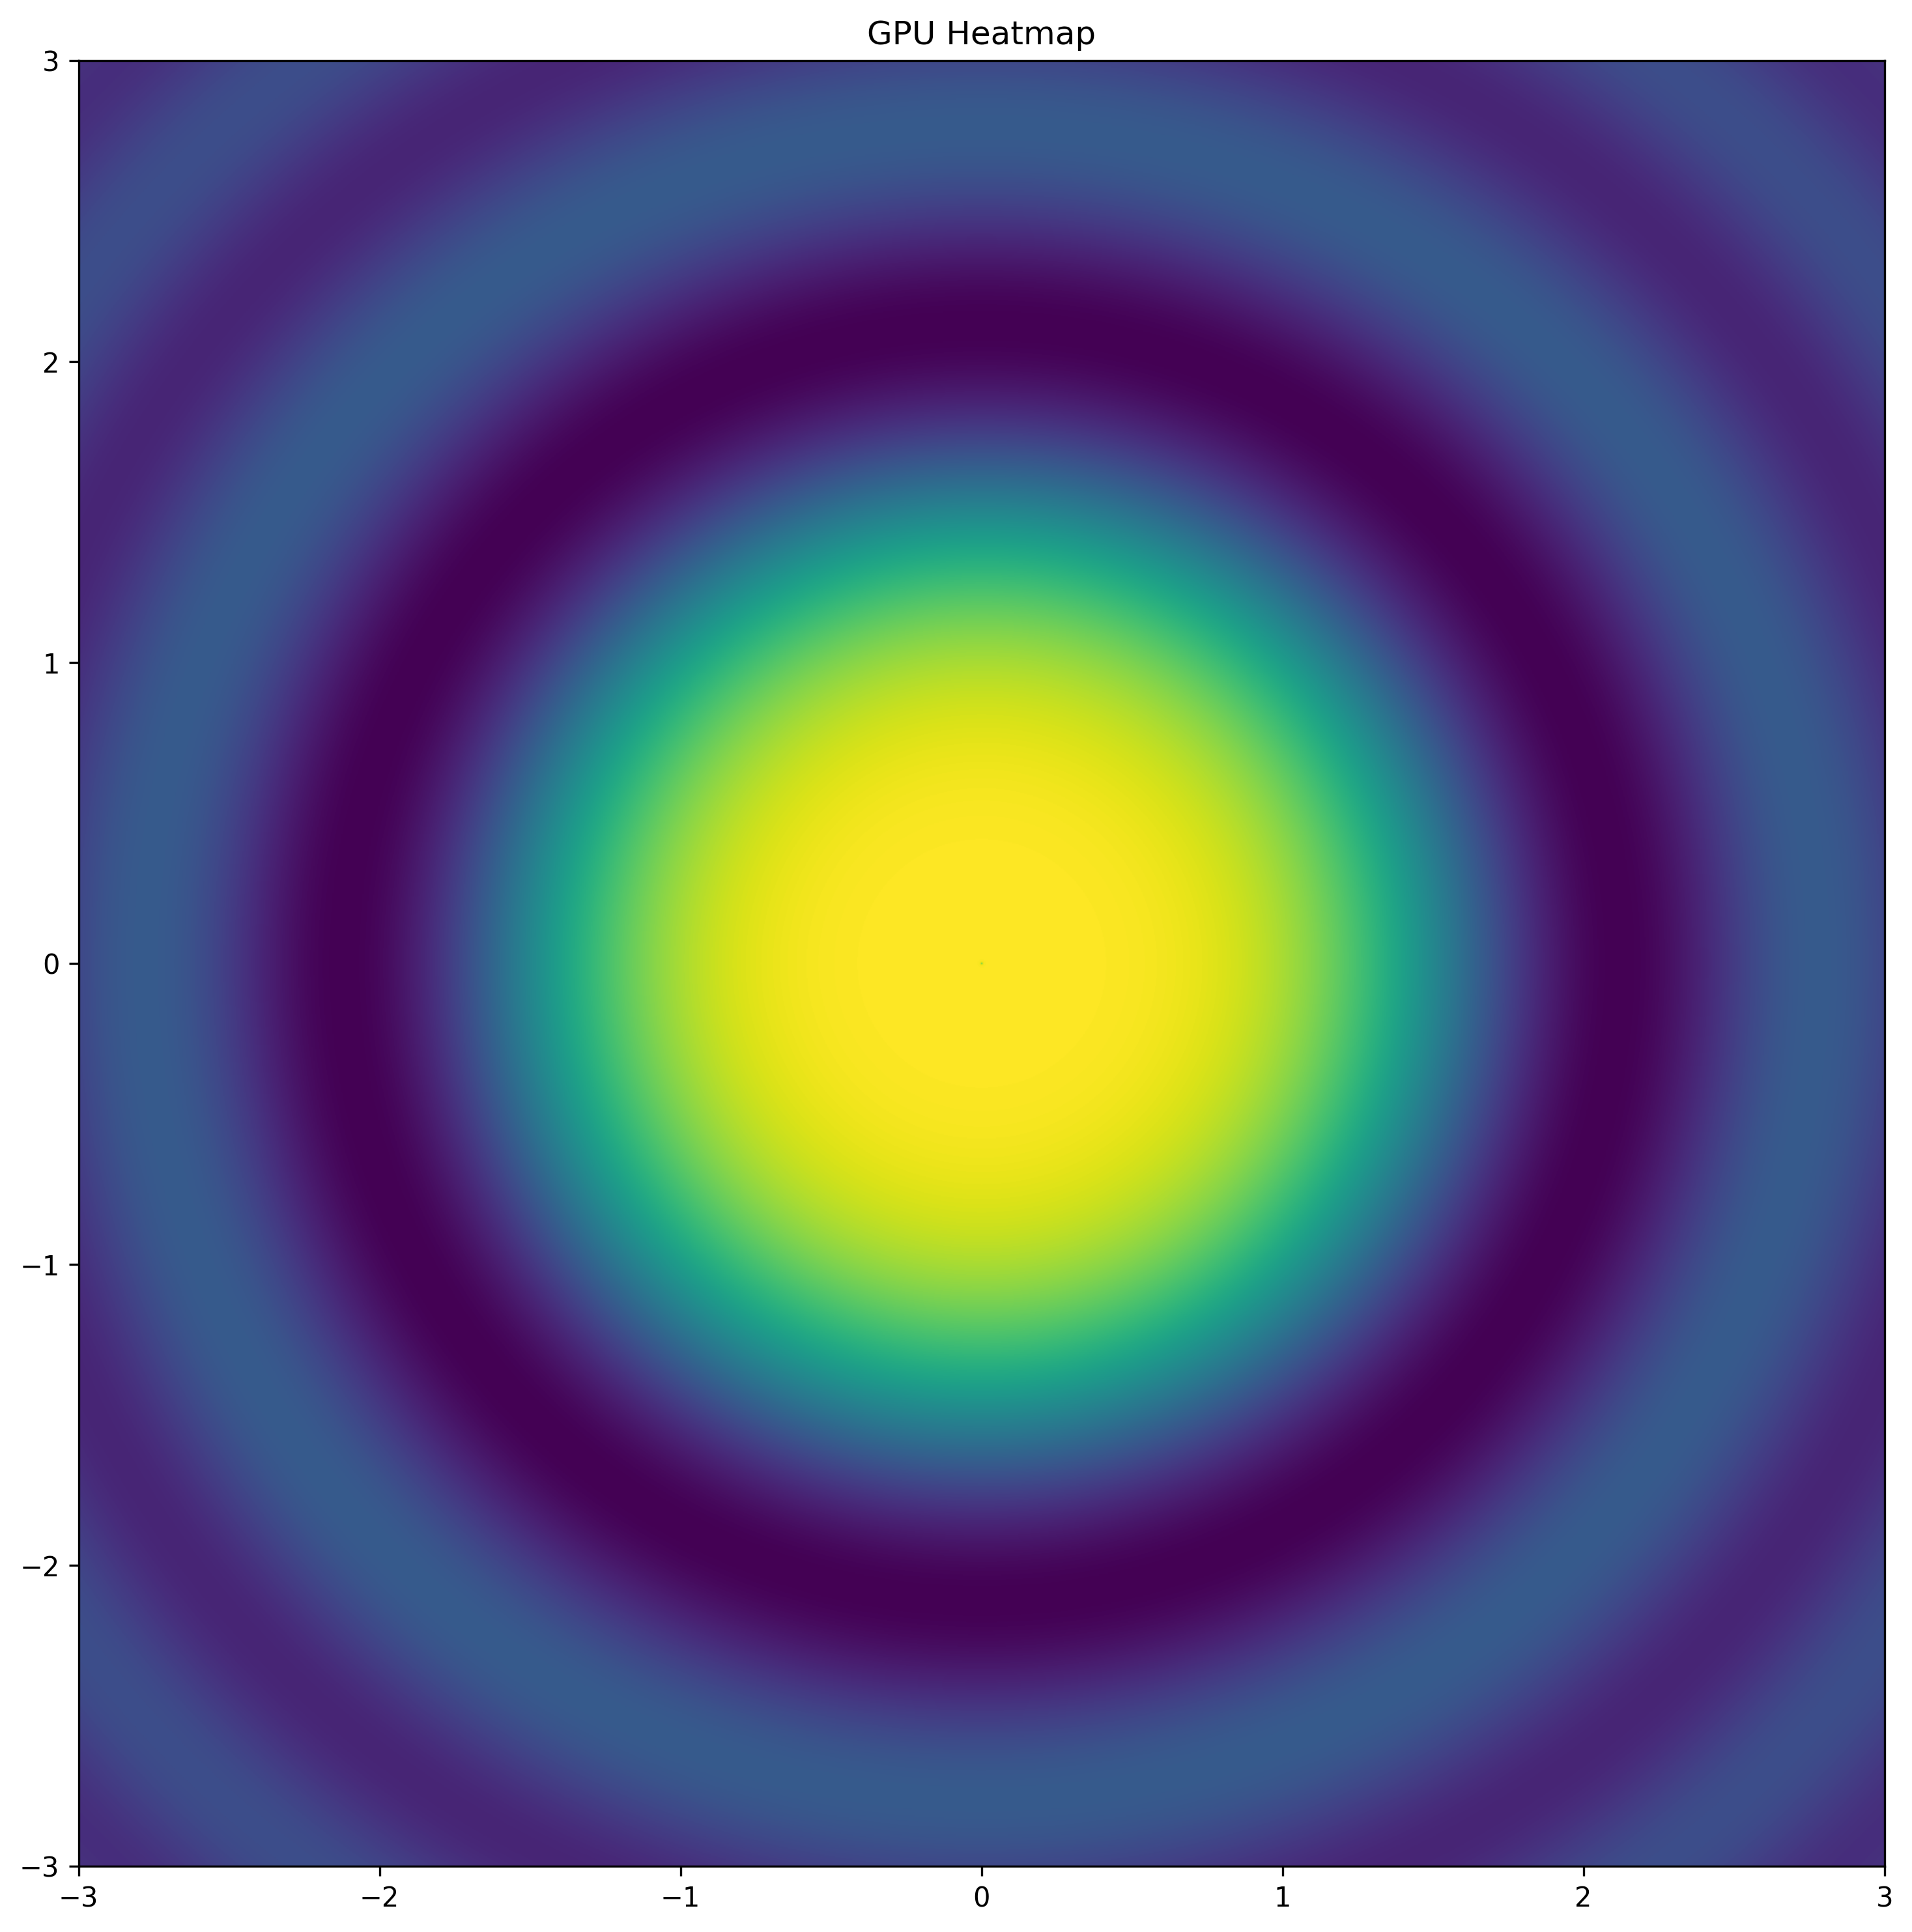

In [56]:
from IPython.display import Image, display
import os

png_path = "gpu_render_output.png" 

if os.path.exists(png_path):
    display(Image(filename=png_path))
else:
    print(f"File not found: {png_path}")

In [53]:
py = sys.executable
script_path = os.path.join(os.getcwd(), "script.py")
print(f" Running with interpreter: {py}")
os.system(f'"{py}" "{script_path}"')

 Running with interpreter: /Users/hafsahshahzad/tvm_env/bin/python3.12
[CPU] Starting heavy computation...
[CPU] Dot product result: 749922.7813
[GPU] Generating large figure...
[GPU] Finished rendering and saved image.
[INFO] Total runtime: 0.98 seconds


0

### Run in Terminal

CPU Time Profiler--->	xcrun xctrace record --template 'Time Profiler' --time-limit 10s --output trace_timeprofile.trace --launch -- python script.py
GPU / Metal ---> xcrun xctrace record --template 'Metal System Trace' --time-limit 10s --output trace_metal.trace --launch -- python script.py
Power & Thermal--->	sudo powermetrics --show-all --samplers cpu_power,gpu_power,thermal -i 1000 -n 30